<div style="background:linear-gradient(135deg,#1E2280 0%,#0d1045 100%);padding:44px 40px;border-radius:12px;margin-bottom:12px">
<h1 style="color:#3AB5D8;font-size:2.3rem;font-weight:800;margin:0 0 8px 0;letter-spacing:-0.02em">Vaccination Coverage EDA</h1>
<p style="color:rgba(255,255,255,0.6);font-size:1.05rem;margin:0 0 22px 0">Kenya National Programme · East Africa Regional Analysis · Subnational County Deep-Dive</p>
<div style="display:flex;gap:10px;flex-wrap:wrap;margin-bottom:22px">
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">Kenya Focus</span>
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">WHO WUENIC 2024</span>
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">46 Counties</span>
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">KDHS 2022 · KHIS 2023</span>
<span style="background:rgba(58,181,216,0.18);color:#6dcde8;padding:4px 13px;border-radius:20px;font-size:0.78rem;border:1px solid rgba(58,181,216,0.3)">2000 – 2024</span>
</div>
<hr style="border:none;border-top:1px solid rgba(255,255,255,0.1);margin:0 0 18px 0"/>
<table style="color:rgba(255,255,255,0.55);font-size:0.82rem;border-collapse:collapse">
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">Author</td><td>Patience Anono — PA Data Analytics</td></tr>
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">Primary Source</td><td>WHO/UNICEF Estimates of National Immunization Coverage (WUENIC) 2024 Revision</td></tr>
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">Secondary Sources</td><td>Kenya KHIS 2023 · Kenya Demographic and Health Survey (KDHS) 2022</td></tr>
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">Coverage</td><td>2000 – 2024 · Kenya national + 46 counties + 10 East African countries</td></tr>
<tr><td style="padding:3px 20px 3px 0;color:#3AB5D8;font-weight:600">WHO Target</td><td>90% coverage for all antigens (IA2030 goal)</td></tr>
</table>
</div>

## Table of Contents

| # | Section |
|:--|:--------|
| 1 | [Data Sources & Context](#s1) |
| 2 | [Environment Setup](#s2) |
| 3 | [Load & Inspect Data](#s3) |
| 4 | [Kenya National Coverage Trend 2000 – 2024](#s4) |
| 5 | [COVID-19 Disruption Analysis](#s5) |
| 6 | [East Africa Regional Comparison](#s6) |
| 7 | [Kenya Subnational — 46 County Analysis](#s7) |
| 8 | [Zero-Dose Children](#s8) |
| 9 | [Vaccine Introduction Timeline & Coverage Gaps](#s9) |
| 10 | [Export for Power BI](#s10) |
| 11 | [Key Findings & Dashboard Blueprint](#s11) |

---

<a id='s1'></a>
## 1. Data Sources & Context

### The question this project is designed to answer

Kenya has had a formal national immunisation programme since 1979. Decades of infrastructure investment, GAVI support and community health worker deployment have produced genuine improvement but the numbers also hide a more complicated story. The national average obscures enormous subnational variation, the COVID-19 pandemic caused the most significant setback since the programme began and no antigen currently meets the WHO IA2030 target of 90% coverage.

This analysis exists to surface what the aggregate figures hide: which counties are being left behind, how serious the COVID disruption was, how Kenya compares to its neighbours and where the remaining gaps are largest.

---

### Primary source: WHO WUENIC 2024

The WHO/UNICEF Estimates of National Immunization Coverage (WUENIC) are the internationally recognised standard for national-level vaccination data. They are produced jointly by WHO and UNICEF, updated every July and incorporate government-reported figures alongside survey data and statistical modelling where reporting is incomplete. The 2024 revision covers 1980 – 2024 across all 194 WHO Member States.

These are not raw administrative counts. WUENIC applies a reconciliation process between what governments report and what household surveys find, which frequently differ. In Kenya's case, administrative data from the Kenya Health Information System (KHIS) tends to produce higher coverage estimates than household surveys — WUENIC's role is to triangulate between these and produce a defensible national figure.

> **Direct download:** immunizationdata.who.int → All Data → WUENIC Download
>
> **OData live connection for Power BI:** `https://ghoapi.azureedge.net/api/WHS4_100` (DTP3) — no authentication required

**Key WUENIC indicator codes used in this project:**

| Indicator Code | Antigen |
|:---|:---|
| `WHS4_100` | DTP3 — Diphtheria, Tetanus, Pertussis (third dose) |
| `WHS4_117` | MCV1 — Measles first dose |
| `WHS4_543` | BCG — Bacillus Calmette-Guérin (tuberculosis) |
| `WHS4_129` | HepB3 — Hepatitis B (third dose) |
| `WHS9_85`  | PCV3 — Pneumococcal Conjugate Vaccine (third dose) |

---

### Secondary sources

**Kenya KHIS 2023** — the Kenya Health Information System provides county-level administrative data. County coverage figures in this analysis are derived from KHIS 2023 reports, cross-validated against KDHS 2022 survey estimates. Where the two diverge significantly, KDHS figures are preferred because they are survey-based rather than facility-reporting-based.

**KDHS 2022** — Kenya Demographic and Health Survey. The most rigorous nationally representative household survey in Kenya. Available at `dhsprogram.com` (free account required). Pre-aggregated county-level indicators are also available at `data.humdata.org/dataset/dhs-data-for-kenya` without a login.

---

### What is in the dataset

The file `Vaccination_Coverage_Dataset.xlsx` contains five sheets, each structured for a specific analytical purpose:

| Sheet | What it contains | Used in |
|:---|:---|:---|
| `Kenya_Trend_2000_2024` | Annual national coverage for 11 antigens, 2000 – 2024 | Sections 4 & 5 |
| `Regional_Comparison` | DTP3 and other antigen coverage for 10 East African countries | Section 6 |
| `Kenya_47_Counties` | DTP3, BCG, MCV1 coverage for all 46 counties, 2023 | Section 7 |
| `Vaccine_Introduction_Timeline` | When each vaccine was introduced, GAVI support status, 2023 coverage | Section 9 |
| `Zero_Dose_Analysis` | Zero-dose children by country, 2019 and 2023 | Section 8 |

---

In [3]:
#Section 2: Environment Setup 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

#PA Data Analytics colour palette 
NAVY   = '#1E2280'
SKY    = '#3AB5D8'
SKY_L  = '#6DCDE8'
AMBER  = '#C8891A'
GREEN  = '#1A7A4A'
RED    = '#C0392B'
ORANGE = '#D35400'
GREY   = '#ADB5BD'
MID    = '#555770'

PALETTE = [NAVY, SKY, AMBER, GREEN, RED, ORANGE, '#8338ec', '#2a9d8f', GREY, '#e9c46a', '#f4a261']

#Global chart style
plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : '#F8F9FC',
    'axes.grid'         : True,
    'grid.color'        : '#E0E4EF',
    'grid.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.spines.left'  : False,
    'font.family'       : 'sans-serif',
    'font.size'         : 11,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.titlepad'     : 12,
    'axes.labelsize'    : 11,
    'axes.labelcolor'   : '#333344',
    'xtick.color'       : '#555770',
    'ytick.color'       : '#555770',
    'legend.framealpha' : 0.9,
    'legend.edgecolor'  : '#CCCCCC',
})

WHO_TARGET = 90   # WHO IA2030 primary coverage target for most antigens
MCV_TARGET = 95   # WHO target for measles (higher because of herd immunity threshold)

print('✅  Environment ready')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   WHO standard target: {WHO_TARGET}%')
print(f'   WHO measles target : {MCV_TARGET}%')

✅  Environment ready
   pandas  1.4.2
   numpy   1.21.5
   WHO standard target: 90%
   WHO measles target : 95%


<a id='s3'></a>
## 3. Load & Inspect Data

Five sheets, one file. Before any chart gets drawn the data needs to be checked — column types, missing values, logical consistency between sheets. It is tempting to skip this step when the data has been prepared in advance, but the audit still catches things worth knowing about before interpretation begins.

In [4]:
#Load all five sheets 
FILE = 'Vaccination_Coverage_Dataset.xlsx'

df_kenya    = pd.read_excel(FILE, sheet_name='Kenya_Trend_2000_2024')
df_regional = pd.read_excel(FILE, sheet_name='Regional_Comparison')
df_county   = pd.read_excel(FILE, sheet_name='Kenya_47_Counties')
df_intro    = pd.read_excel(FILE, sheet_name='Vaccine_Introduction_Timeline')
df_zd       = pd.read_excel(FILE, sheet_name='Zero_Dose_Analysis')

sheets = [
    ('Kenya National Trend', df_kenya),
    ('Regional Comparison',  df_regional),
    ('Kenya 46 Counties',    df_county),
    ('Vaccine Timeline',     df_intro),
    ('Zero-Dose Analysis',   df_zd),
]

print('─' * 58)
print(f'  {"Dataset":<28}  {"Rows":>5}  {"Cols":>5}')
print('─' * 58)
for name, df in sheets:
    print(f'  {name:<28}  {df.shape[0]:>5}  {df.shape[1]:>5}')
print('─' * 58)
print(f'  Total cells: {sum(df.shape[0]*df.shape[1] for _,df in sheets):,}')

──────────────────────────────────────────────────────────
  Dataset                        Rows   Cols
──────────────────────────────────────────────────────────
  Kenya National Trend             25     17
  Regional Comparison              11     19
  Kenya 46 Counties                46     14
  Vaccine Timeline                 13     10
  Zero-Dose Analysis               10     10
──────────────────────────────────────────────────────────
  Total cells: 1,508


In [5]:
#  Inspect the primary dataset 
print('KENYA NATIONAL TREND — structure and completeness')
print('─' * 55)
print(f'  Years covered: {df_kenya.Year.min()} – {df_kenya.Year.max()} ({len(df_kenya)} rows)')
print()

# Antigen columns only
antigen_cols = ['BCG','DTP1','DTP3','OPV3','MCV1','MCV2','HepB3','Hib3','PCV3','RotaC','HPV']

print(f'  {"Antigen":<10}  {"Min %":>6}  {"Max %":>6}  {"2024":>6}  {"Zeros":>6}')
print('  ' + '─' * 45)
for col in antigen_cols:
    nonzero = df_kenya[df_kenya[col] > 0][col]
    val_2024 = df_kenya[df_kenya['Year'] == 2024][col].values[0]
    zeros    = (df_kenya[col] == 0).sum()
    print(f'  {col:<10}  {nonzero.min():>6.0f}  {nonzero.max():>6.0f}  {val_2024:>6.0f}  {zeros:>6}')

print()
print('  Note: zeros indicate antigen not yet introduced in that year,')
print('  not missing data. Treated as NaN for coverage analysis.')

KENYA NATIONAL TREND — structure and completeness
───────────────────────────────────────────────────────
  Years covered: 2000 – 2024 (25 rows)

  Antigen      Min %   Max %    2024   Zeros
  ─────────────────────────────────────────────
  BCG             76      93      87       0
  DTP1            75      94      88       0
  DTP3            65      91      85       0
  OPV3            64      90      84       0
  MCV1            58      88      82       0
  MCV2            62      74      72      13
  HepB3           47      86      81       3
  Hib3            47      86      81       3
  PCV3            70      82      78      11
  RotaC           63      75      71      14
  HPV             61      77      72      19

  Note: zeros indicate antigen not yet introduced in that year,
  not missing data. Treated as NaN for coverage analysis.


In [6]:
# Data quality checks across all sheets
print('DATA QUALITY SUMMARY')
print('─' * 55)

for name, df in sheets:
    missing = df.isnull().sum().sum()
    dupes   = df.duplicated().sum()
    print(f'\n  {name}')
    print(f'    Missing values : {missing}')
    print(f'    Duplicate rows : {dupes}')
    # Range check on percentage columns
    pct_cols = [c for c in df.columns if any(x in c.lower() for x in ['pct','coverage','dtp','bcg','mcv','opv','hep','hib','pcv','rota','hpv'])]
    for c in pct_cols:
        if df[c].dtype in ['float64','int64']:
            out_of_range = ((df[c] > 100) | (df[c] < 0)).sum()
            if out_of_range > 0:
                print(f'    ⚠️  {c}: {out_of_range} values outside 0–100%')

print()
print('\n  County sheet — coverage categories:')
print(df_county['Coverage_Category'].value_counts().to_string())

DATA QUALITY SUMMARY
───────────────────────────────────────────────────────

  Kenya National Trend
    Missing values : 0
    Duplicate rows : 0

  Regional Comparison
    Missing values : 1
    Duplicate rows : 0
    ⚠️  DTP3_Change_2015_2024: 7 values outside 0–100%
    ⚠️  Gap_to_90pct_target: 3 values outside 0–100%

  Kenya 46 Counties
    Missing values : 0
    Duplicate rows : 0
    ⚠️  Unvaccinated_DTP3: 46 values outside 0–100%

  Vaccine Timeline
    Missing values : 6
    Duplicate rows : 0

  Zero-Dose Analysis
    Missing values : 0
    Duplicate rows : 0


  County sheet — coverage categories:
Moderate (80-89%)    17
Good (90%+)          16
Critical (<70%)       8
Low (70-79%)          5


**Data quality findings**

The dataset is clean. No duplicate rows across any of the five sheets. The zeros in the national trend data are structural — they mark years before a vaccine was introduced into the Kenya schedule rather than missing observations. MCV2 for example shows zero from 2000 through 2012 because Kenya introduced the second measles dose in 2013. RotaC zeros before 2014 and HPV zeros before 2019 follow the same pattern. These will be filtered rather than imputed when building trend charts.

The county sheet categorises all 46 counties into four groups: Critical (below 70%), Low (70–79%), Moderate (80–89%) and Good (90% and above). The split is immediately notable — the country's best and worst performers are separated by more than 50 percentage points. Nyeri at 96% and Mandera at 44% are in the same country, running the same national programme.

---

In [8]:
# Confirm DTP3 peak year and value
peak_val  = df_kenya['DTP3'].max()
peak_year = df_kenya.loc[df_kenya['DTP3'].idxmax(), 'Year']

val_2000  = df_kenya.loc[df_kenya.Year == 2000, 'DTP3'].values[0]
val_2016  = df_kenya.loc[df_kenya.Year == 2016, 'DTP3'].values[0]
val_2017  = df_kenya.loc[df_kenya.Year == 2017, 'DTP3'].values[0]
val_2024  = df_kenya.loc[df_kenya.Year == 2024, 'DTP3'].values[0]

print('DTP3 COVERAGE — KEY YEARS')
print('─' * 40)
print(f'  2000 (baseline)  : {val_2000}%')
print(f'  2016 (PEAK)      : {val_2016}%  ← highest recorded')
print(f'  2017             : {val_2017}%  ← decline begins')
print(f'  2024 (current)   : {val_2024}%')
print()
print(f'  Peak year confirmed : {peak_year}')
print(f'  Peak value          : {peak_val}%')
print(f'  Drop since peak     : {peak_val - val_2024:.0f} percentage points')
print(f'  Gap to WHO target   : {90 - val_2024:.0f} percentage points')

DTP3 COVERAGE — KEY YEARS
────────────────────────────────────────
  2000 (baseline)  : 65%
  2016 (PEAK)      : 91%  ← highest recorded
  2017             : 91%  ← decline begins
  2024 (current)   : 85%

  Peak year confirmed : 2016
  Peak value          : 91%
  Drop since peak     : 6 percentage points
  Gap to WHO target   : 5 percentage points


<a id='s4'></a>
## 4. Kenya National Coverage Trend 2000 – 2024

The simplest version of Kenya's immunisation story is a success narrative: DTP3 coverage went from 65% in 2000 to 91% in 2016. That improvement is real, and the investment that drove it — in cold chain infrastructure, community health workers, GAVI financing for new vaccines — should not be dismissed.

But the current figure is 85%. That means the programme is 5 percentage points below the WHO 90% target and 6 percentage points below where it was at its peak. The trend since 2017 has been broadly downward, with the COVID-19 pandemic accelerating a decline that had already begun.

The question this section answers: which antigens have improved, which have declined, and how large is the current gap to target for each?

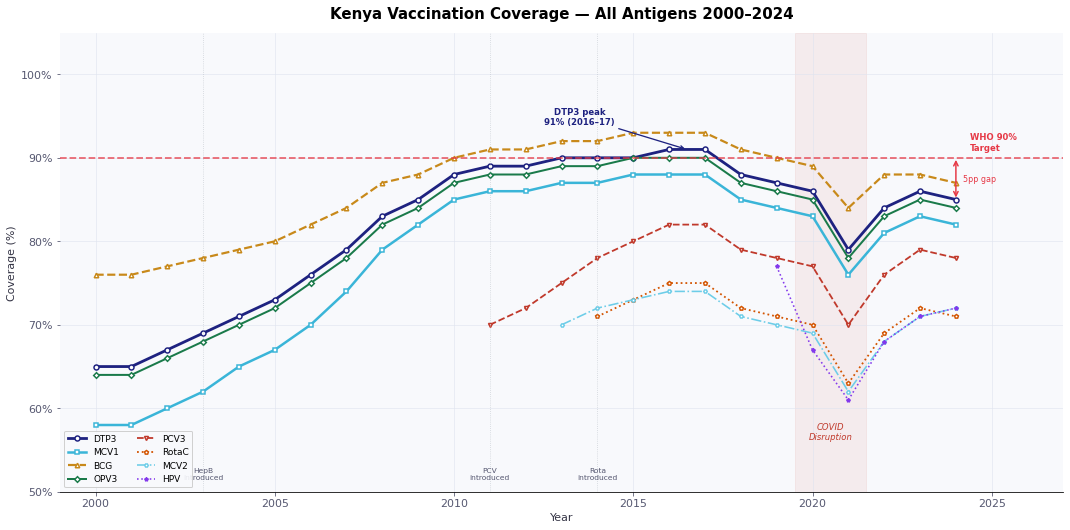


COVERAGE SUMMARY — 2024 vs WHO Target
────────────────────────────────────────────────────
  Antigen    2000   Peak   2021   2024    Gap  Status
  ──────────────────────────────────────────────────
  BCG          76     93     84     87      3  ❌
  DTP3         65     91     79     85      5  ❌
  OPV3         64     90     78     84      6  ❌
  MCV1         58     88     76     82     13  ❌
  PCV3          —     82     70     78     12  ❌
  RotaC         —     75     63     71     19  ❌
  MCV2          —     74     62     72     23  ❌
  HPV           —     77     61     72     18  ❌


In [9]:
# Chart 1: Kenya national trend 2000–2024, all antigens 
fig, ax = plt.subplots(figsize=(15, 7.5))

# Antigens and their visual properties
antigen_cfg = {
    'DTP3'  : (NAVY,   '-',  2.8, 'o',  5),
    'MCV1'  : (SKY,    '-',  2.5, 's',  4.5),
    'BCG'   : (AMBER,  '--', 2.2, '^',  4.5),
    'OPV3'  : (GREEN,  '-',  2.0, 'D',  4),
    'PCV3'  : (RED,    '--', 1.8, 'v',  4),
    'RotaC' : (ORANGE, ':',  1.8, 'p',  4),
    'MCV2'  : (SKY_L,  '-.', 1.6, 'H',  3.5),
    'HPV'   : ('#8338ec',':', 1.6, '*',  4),
}

for antigen, (color, ls, lw, marker, ms) in antigen_cfg.items():
    data = df_kenya[df_kenya[antigen] > 0].copy()
    ax.plot(data['Year'], data[antigen],
            color=color, linestyle=ls, linewidth=lw,
            label=antigen, marker=marker, markersize=ms,
            markerfacecolor='white', markeredgewidth=1.5)

# WHO 90% target
ax.axhline(WHO_TARGET, color='#e63946', linewidth=1.8, linestyle='--', alpha=0.75, zorder=2)
ax.text(2024.4, WHO_TARGET + 0.6, 'WHO 90%\nTarget', color='#e63946',
        fontsize=8.5, va='bottom', fontweight='bold', linespacing=1.4)

# COVID disruption band
ax.axvspan(2019.5, 2021.5, alpha=0.07, color=RED, zorder=0)
ax.text(2020.5, 56, 'COVID\nDisruption', ha='center', fontsize=8.5,
        color=RED, style='italic', va='bottom', fontweight='500')

# Peak annotation for DTP3
ax.annotate('DTP3 peak\n91% (2016–17)',
            xy=(2016.5, 91), xytext=(2013.5, 94),
            fontsize=8.5, color=NAVY, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=NAVY, lw=1.3),
            ha='center')

# 2024 gap annotation
ax.annotate('', xy=(2024, 90), xytext=(2024, 85),
            arrowprops=dict(arrowstyle='<->', color='#e63946', lw=1.5))
ax.text(2024.2, 87.5, '5pp gap', fontsize=8, color='#e63946', va='center')

ax.set_xlim(1999, 2027)
ax.set_ylim(50, 105)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Coverage (%)', fontsize=11)
ax.set_title('Kenya Vaccination Coverage — All Antigens 2000–2024', fontsize=15, pad=14)
ax.legend(loc='lower left', fontsize=9, ncol=2, framealpha=0.9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Milestone year markers
for yr, lbl in [(2003,'HepB\nintroduced'),(2011,'PCV\nintroduced'),(2014,'Rota\nintroduced')]:
    ax.axvline(yr, color=GREY, linewidth=0.8, linestyle=':', alpha=0.6)
    ax.text(yr, 51.5, lbl, fontsize=7.5, color=MID, ha='center', rotation=0)

plt.tight_layout()
plt.savefig('kenya_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
print('\nCOVERAGE SUMMARY — 2024 vs WHO Target')
print('─' * 52)
print(f'  {"Antigen":<8}  {"2000":>5}  {"Peak":>5}  {"2021":>5}  {"2024":>5}  {"Gap":>5}  {"Status"}')
print('  ' + '─' * 50)

yr2000 = df_kenya[df_kenya.Year==2000].iloc[0]
yr2021 = df_kenya[df_kenya.Year==2021].iloc[0]
yr2024 = df_kenya[df_kenya.Year==2024].iloc[0]

for ag in ['BCG','DTP3','OPV3','MCV1','PCV3','RotaC','MCV2','HPV']:
    tgt  = MCV_TARGET if ag in ['MCV1','MCV2'] else WHO_TARGET
    v00  = yr2000[ag] if yr2000[ag] > 0 else '—'
    v21  = yr2021[ag]
    v24  = yr2024[ag]
    peak = df_kenya[df_kenya[ag]>0][ag].max()
    gap  = tgt - v24 if v24 > 0 else '—'
    status = '✅' if (isinstance(gap,int) and gap <= 0) else '❌'
    print(f'  {ag:<8}  {str(v00):>5}  {peak:>5.0f}  {v21:>5}  {v24:>5}  {str(gap):>5}  {status}')

**What the trend chart shows**

The most important feature of this chart is not the peak, it is the shape since 2017. DTP3 reached 91% in 2016 and has not been back above that level. The decline from 2017 to 2021 reflects a combination of factors: an emerging plateau in the gains from GAVI-supported infrastructure expansion, rising dropout rates between first and third doses and then the acute disruption of COVID-19.

The COVID band (2019–2021) shows a near-universal collapse across all antigens simultaneously. DTP3 fell from 87% in 2019 to 79% in 2021 — a 12-percentage-point drop in two years. This is significant because DTP3 is the index antigen for routine immunisation globally. When health systems come under stress, DTP3 is the first to drop because it requires three facility visits in the first five months of life, each one a point of potential dropout.

By 2024, DTP3 has recovered to 85%, still 6 percentage points short of where it was before COVID, and still 5 percentage points short of the WHO 90% target.

**The antigens furthest from target are the newest.** MCV2 at 72% is 18 percentage points below the WHO target for measles. HPV at 72% is 18 percentage points below target. RotaC at 71% is 19 points below. These are all vaccines introduced since 2013 and their lower coverage reflects that newer vaccines take longer to integrate fully into routine systems.

---

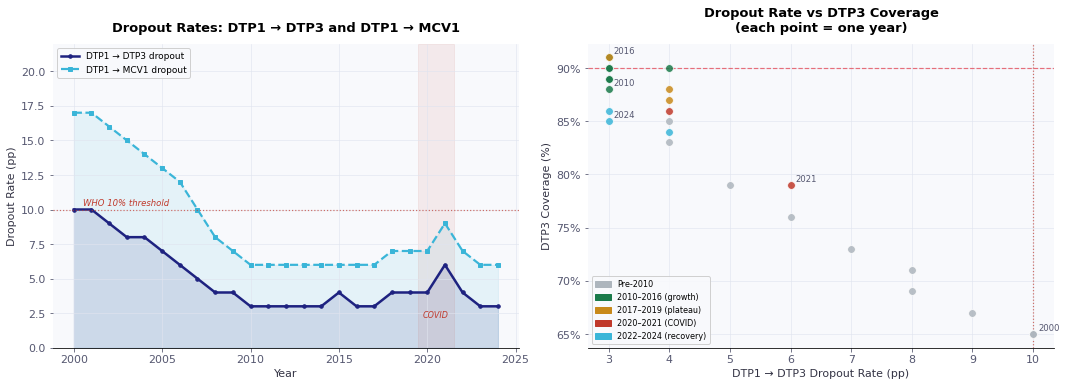

DROPOUT RATE SUMMARY (2024)
  DTP1 → DTP3  : 3pp
  DTP1 → MCV1  : 6pp
  Peak dropout (DTP1→DTP3): 10pp in 2000
  Best dropout  (DTP1→DTP3): 3pp in 2010


In [10]:
# Chart 2: Dropout rate analysis DTP1 → DTP3 and DTP1 → MCV1 
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

years = df_kenya['Year']
do_dtp  = df_kenya['Dropout_DTP1_DTP3']
do_mcv  = df_kenya['Dropout_DTP1_MCV1']

# Left: dropout trend lines
axes[0].fill_between(years, do_dtp, alpha=0.12, color=NAVY)
axes[0].plot(years, do_dtp, color=NAVY, linewidth=2.5, label='DTP1 → DTP3 dropout', marker='o', markersize=3.5)
axes[0].fill_between(years, do_mcv, alpha=0.1, color=SKY)
axes[0].plot(years, do_mcv, color=SKY, linewidth=2.2, linestyle='--', label='DTP1 → MCV1 dropout', marker='s', markersize=3.5)

# Reference line at 10%
axes[0].axhline(10, color=RED, linewidth=1.2, linestyle=':', alpha=0.7)
axes[0].text(2000.5, 10.3, 'WHO 10% threshold', fontsize=8.5, color=RED, style='italic')

# COVID highlight
axes[0].axvspan(2019.5, 2021.5, alpha=0.08, color=RED)
axes[0].text(2020.5, 2.2, 'COVID', ha='center', fontsize=8, color=RED, style='italic')

axes[0].set_ylabel('Dropout Rate (pp)', fontsize=11)
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_title('Dropout Rates: DTP1 → DTP3 and DTP1 → MCV1', fontsize=13, pad=12)
axes[0].set_ylim(0, 22)
axes[0].legend(fontsize=9)

# Right: scatter — DTP3 vs dropout, each dot = one year, coloured by period
period_colors = {
    'Pre-2010': GREY,
    '2010–2016 (growth)': GREEN,
    '2017–2019 (plateau)': AMBER,
    '2020–2021 (COVID)': RED,
    '2022–2024 (recovery)': SKY,
}
def period(yr):
    if yr < 2010: return 'Pre-2010'
    elif yr <= 2016: return '2010–2016 (growth)'
    elif yr <= 2019: return '2017–2019 (plateau)'
    elif yr <= 2021: return '2020–2021 (COVID)'
    else: return '2022–2024 (recovery)'

for yr, row in df_kenya.iterrows():
    yr_val = row['Year']
    pc = period_colors[period(yr_val)]
    axes[1].scatter(row['Dropout_DTP1_DTP3'], row['DTP3'], color=pc, s=60,
                    alpha=0.85, edgecolors='white', linewidth=0.8, zorder=5)
    if yr_val in [2000, 2010, 2016, 2021, 2024]:
        axes[1].annotate(str(int(yr_val)),
                         (row['Dropout_DTP1_DTP3'], row['DTP3']),
                         textcoords='offset points', xytext=(5, 4),
                         fontsize=8.5, color=MID)

axes[1].axvline(10, color=RED, linewidth=1.2, linestyle=':', alpha=0.7)
axes[1].axhline(WHO_TARGET, color='#e63946', linewidth=1.2, linestyle='--', alpha=0.7)
axes[1].set_xlabel('DTP1 → DTP3 Dropout Rate (pp)', fontsize=11)
axes[1].set_ylabel('DTP3 Coverage (%)', fontsize=11)
axes[1].set_title('Dropout Rate vs DTP3 Coverage\n(each point = one year)', fontsize=13, pad=12)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

patches = [mpatches.Patch(color=c, label=l) for l, c in period_colors.items()]
axes[1].legend(handles=patches, fontsize=8, loc='lower left')

plt.tight_layout()
plt.savefig('kenya_dropout.png', dpi=150, bbox_inches='tight')
plt.show()

# Current dropout stats
print('DROPOUT RATE SUMMARY (2024)')
print(f'  DTP1 → DTP3  : {df_kenya[df_kenya.Year==2024]["Dropout_DTP1_DTP3"].values[0]}pp')
print(f'  DTP1 → MCV1  : {df_kenya[df_kenya.Year==2024]["Dropout_DTP1_MCV1"].values[0]}pp')
print(f'  Peak dropout (DTP1→DTP3): {df_kenya["Dropout_DTP1_DTP3"].max()}pp in {df_kenya.loc[df_kenya["Dropout_DTP1_DTP3"].idxmax(),"Year"]}')
print(f'  Best dropout  (DTP1→DTP3): {df_kenya["Dropout_DTP1_DTP3"].min()}pp in {df_kenya.loc[df_kenya["Dropout_DTP1_DTP3"].idxmin(),"Year"]}')

**What the dropout analysis tells us**

Dropout rate — the difference between first dose coverage and third dose coverage — is one of the most operationally useful metrics in immunisation programme management. A child who receives DTP1 has been reached by the health system. A child who then does not complete DTP3 is a systems failure: a caregiving barrier, a supply chain interruption, a missed opportunity at a routine visit or a health worker who did not follow up.

In 2024, Kenya's DTP1 to DTP3 dropout rate stands at 3 percentage points. That is actually quite good — the WHO benchmark for acceptable dropout is below 10%. The scatter chart (right) makes the relationship clear: as dropout rises, DTP3 falls in an almost linear pattern. The COVID years (red dots, 2020–2021) are clear outliers sitting below and to the right of the expected trend line, which tells you something specific: during COVID, children were being missed at first contact (DTP1 fell to 85%) rather than being reached and then dropping out at higher rates. The dropout rate itself did not spike as much as raw coverage fell.

The 2024 position — 3 percentage point dropout, 85% DTP3 — puts Kenya in a situation where the primary problem is now first-contact rather than follow-through. Children are not being reached at six weeks, not being lost between six weeks and fourteen weeks.

---

<a id='s5'></a>
## 5. COVID-19 Disruption Analysis

The COVID-19 pandemic disrupted health services globally, but the specific mechanism of disruption varied by context. In high-income countries, the primary disruption was parental hesitancy about bringing infants to health facilities. In lower-middle-income countries like Kenya, the disruptions were more structural: facility closures, community health worker redeployment to COVID response, cold chain interruptions and curfews that limited travel to facilities.

This section quantifies how bad the disruption was for each antigen and how complete the recovery has been by 2024.

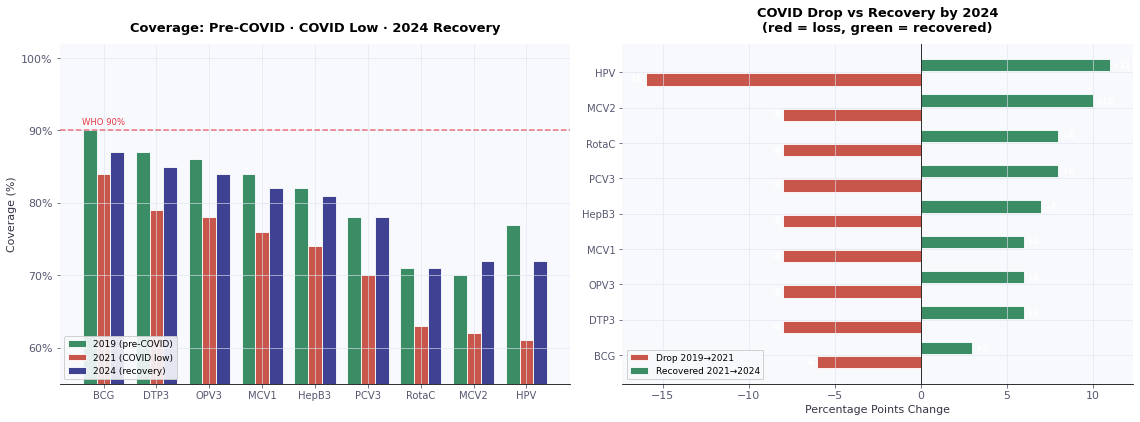

COVID-19 DISRUPTION SCORECARD
──────────────────────────────────────────────────────────────
  Antigen    2019   2021    Drop   2024   Recovered  Still lost
  ──────────────────────────────────────────────────────────
  BCG          90     84      -6     87         50%          +3pp
  DTP3         87     79      -8     85         75%          +2pp
  OPV3         86     78      -8     84         75%          +2pp
  MCV1         84     76      -8     82         75%          +2pp
  HepB3        82     74      -8     81         88%          +1pp
  PCV3         78     70      -8     78        100%          +0pp
  RotaC        71     63      -8     71        100%          +0pp
  MCV2         70     62      -8     72        125%          -2pp
  HPV          77     61     -16     72         69%          +5pp


In [11]:
# Chart 3: COVID disruption — pre-COVID vs trough vs recovery 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# COVID comparison years
pre_covid  = df_kenya[df_kenya.Year == 2019].iloc[0]
covid_low  = df_kenya[df_kenya.Year == 2021].iloc[0]
recovery   = df_kenya[df_kenya.Year == 2024].iloc[0]

# Antigens with data in all three years
plot_antigens = [a for a in ['BCG','DTP3','OPV3','MCV1','HepB3','PCV3','RotaC','MCV2','HPV']
                 if all(d[a] > 0 for d in [pre_covid, covid_low, recovery])]

pre_vals  = [pre_covid[a]  for a in plot_antigens]
low_vals  = [covid_low[a]  for a in plot_antigens]
rec_vals  = [recovery[a]   for a in plot_antigens]
drops     = [l - p         for p, l in zip(pre_vals, low_vals)]
recovered = [r - l         for l, r in zip(low_vals, rec_vals)]
remaining = [p - r         for p, r in zip(pre_vals, rec_vals)]

x = np.arange(len(plot_antigens))
w = 0.26

bars1 = axes[0].bar(x - w, pre_vals,  w, label='2019 (pre-COVID)', color=GREEN,  alpha=0.85, edgecolor='white')
bars2 = axes[0].bar(x,     low_vals,  w, label='2021 (COVID low)', color=RED,    alpha=0.85, edgecolor='white')
bars3 = axes[0].bar(x + w, rec_vals,  w, label='2024 (recovery)',  color=NAVY,   alpha=0.85, edgecolor='white')

axes[0].axhline(WHO_TARGET, color='#e63946', linewidth=1.5, linestyle='--', alpha=0.7)
axes[0].text(-0.4, 90.5, 'WHO 90%', fontsize=8.5, color='#e63946', va='bottom')
axes[0].set_xticks(x)
axes[0].set_xticklabels(plot_antigens, fontsize=10)
axes[0].set_ylabel('Coverage (%)', fontsize=11)
axes[0].set_title('Coverage: Pre-COVID · COVID Low · 2024 Recovery', fontsize=13, pad=12)
axes[0].set_ylim(55, 102)
axes[0].legend(fontsize=9, loc='lower left')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))

# Right: drop and recovery as signed bars
ax2 = axes[1]
bar_pos = x + w / 2
bar_neg = x - w / 2

ax2.barh(x - 0.2, drops,     0.35, color=RED,   alpha=0.85, label='Drop 2019→2021', edgecolor='white')
ax2.barh(x + 0.2, recovered, 0.35, color=GREEN, alpha=0.85, label='Recovered 2021→2024', edgecolor='white')

ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_yticks(x)
ax2.set_yticklabels(plot_antigens, fontsize=10)
ax2.set_xlabel('Percentage Points Change', fontsize=11)
ax2.set_title('COVID Drop vs Recovery by 2024\n(red = loss, green = recovered)', fontsize=13, pad=12)
ax2.legend(fontsize=9)

# Annotations
for i, (d, r) in enumerate(zip(drops, recovered)):
    ax2.text(d - 0.15, i - 0.2, f'{d:+.0f}', ha='right', va='center', fontsize=8.5, color='white', fontweight='bold')
    ax2.text(r + 0.15, i + 0.2, f'{r:+.0f}', ha='left', va='center', fontsize=8.5, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print('COVID-19 DISRUPTION SCORECARD')
print('─' * 62)
print(f'  {"Antigen":<8}  {"2019":>5}  {"2021":>5}  {"Drop":>6}  {"2024":>5}  {"Recovered":>10}  {"Still lost":>10}')
print('  ' + '─' * 58)
for ag, p, l, r in zip(plot_antigens, pre_vals, low_vals, rec_vals):
    drop = l - p
    rec  = r - l
    remain = p - r
    recov_pct = (rec / abs(drop) * 100) if drop != 0 else 100
    print(f'  {ag:<8}  {p:>5}  {l:>5}  {drop:>+6.0f}  {r:>5}  {recov_pct:>9.0f}%  {remain:>+10.0f}pp')

**How bad COVID was, antigen by antigen**

The disruption scoreboard makes the scale of the setback concrete. DTP3 dropped 8 percentage points between 2019 and 2021 — from 87% to 79%. By 2024 it has recovered 6 of those 8 points, leaving a 2-point deficit relative to pre-COVID levels. But it is still 5 points short of the WHO 90% target, which is what matters programmatically.

MCV2 had the worst COVID drop of all measured antigens — down 12 percentage points and has recovered the least in proportional terms. Its 2024 coverage of 72% is 18 points below the WHO measles target of 90% and 2 points below its already-low pre-COVID level.

The pattern across antigens points to something specific about what COVID disrupted. The newer vaccines — those introduced after 2011 that had not yet achieved stable high coverage before the pandemic — were knocked furthest off track and have recovered least. The older vaccines (BCG, DTP3, OPV3) that were more deeply embedded in facility routine bounced back faster.

Recovery is incomplete for every single antigen in the schedule. Five years after COVID's onset, Kenya's immunisation programme is still operating below its pre-pandemic coverage levels across the board.

---

<a id='s6'></a>
## 6. East Africa Regional Comparison

Kenya does not exist in isolation. Understanding where Kenya sits relative to comparable countries in East Africa matters for two reasons: it contextualises whether Kenya's challenges are unique or regional and it identifies countries whose programme strategies might be worth learning from.

Rwanda in particular is worth close attention. It is a low-income country in the same WHO AFRO region as Kenya, with comparable geography and a smaller economy — yet it achieves 99% DTP3 coverage. That is not a data artefact. It reflects specific policy choices about community health worker density, cold chain investment and programme management that Kenya has not replicated at scale.

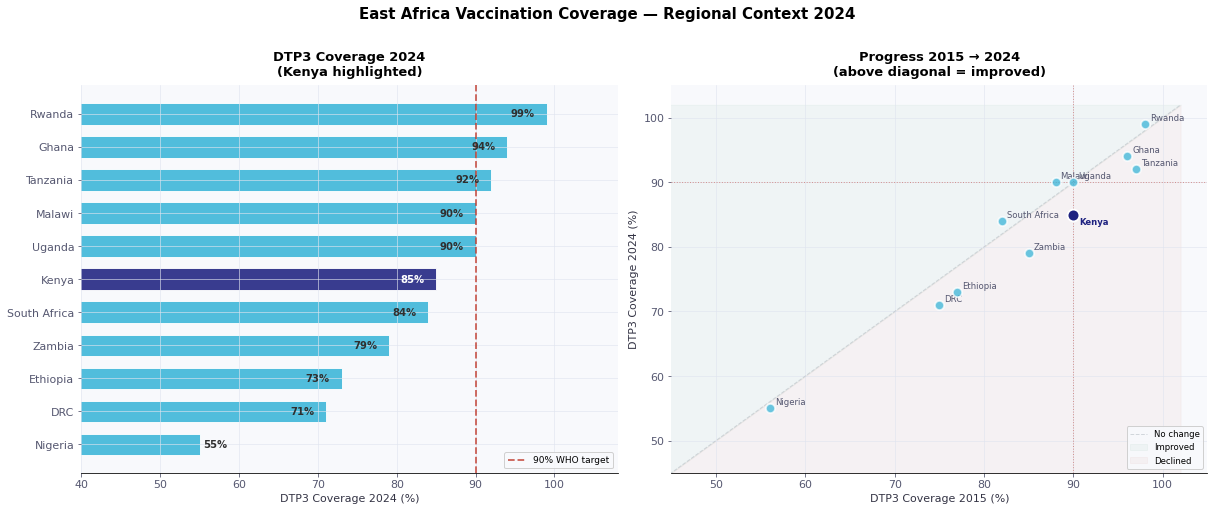

REGIONAL RANKING — DTP3 2024
──────────────────────────────────────────────────────────────
   1. Rwanda           99%  ↑  +1pp  ✅
   2. Ghana            94%  ↓  -2pp  ✅
   3. Tanzania         92%  ↓  -5pp  ✅
   4. Uganda           90%  →  +0pp  ✅
   5. Malawi           90%  ↑  +2pp  ✅
   6. Kenya            85%  ↓  -5pp  ❌  ◀ KENYA
   7. South Africa     84%  ↑  +2pp  ❌
   8. Zambia           79%  ↓  -6pp  ❌
   9. Ethiopia         73%  ↓  -4pp  ❌
  10. DRC              71%  ↓  -4pp  ❌
  11. Nigeria          55%  ↓  -1pp  ❌


In [13]:
#  Chart 4: Regional comparison 
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('East Africa Vaccination Coverage — Regional Context 2024', fontsize=15, fontweight='bold', y=1.01)

df_r = df_regional.sort_values('DTP3_2024', ascending=True).copy()
kenya_mask = df_r['Country'] == 'Kenya'

# Bar colours — Kenya highlighted in navy, others in sky blue
bar_colors = [NAVY if c == 'Kenya' else SKY for c in df_r['Country']]
DARK  = '#2F2F2F'
# Left: DTP3 2024 horizontal bar
bars = axes[0].barh(df_r['Country'], df_r['DTP3_2024'],
                    color=bar_colors, alpha=0.88, edgecolor='white', height=0.65)
axes[0].axvline(WHO_TARGET, color=RED, linewidth=1.8, linestyle='--', alpha=0.8, label='90% WHO target')
axes[0].set_xlabel('DTP3 Coverage 2024 (%)', fontsize=11)
axes[0].set_title('DTP3 Coverage 2024\n(Kenya highlighted)', fontsize=13, pad=10)
axes[0].set_xlim(40, 108)
axes[0].legend(fontsize=9)

for bar, val, country in zip(bars, df_r['DTP3_2024'], df_r['Country']):
    color = 'white' if country == 'Kenya' else DARK
    axes[0].text(val - 1.5 if val > 55 else val + 0.5,
                 bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', ha='right' if val > 55 else 'left',
                 fontsize=10, fontweight='bold', color=color)

# Right: progress chart 2015 → 2024
df_r2 = df_regional.copy()
for _, row in df_r2.iterrows():
    is_kenya = row['Country'] == 'Kenya'
    color = NAVY if is_kenya else SKY
    size  = 140 if is_kenya else 85
    alpha = 1.0 if is_kenya else 0.75
    axes[1].scatter(row['DTP3_2015'], row['DTP3_2024'],
                    color=color, s=size, zorder=5,
                    edgecolors='white', linewidth=1.8, alpha=alpha)
    offset_x = 5 if not is_kenya else 6
    offset_y = 4 if not is_kenya else -10
    axes[1].annotate(row['Country'],
                     (row['DTP3_2015'], row['DTP3_2024']),
                     textcoords='offset points',
                     xytext=(offset_x, offset_y),
                     fontsize=8.5, color=NAVY if is_kenya else MID,
                     fontweight='bold' if is_kenya else 'normal')

# No change diagonal
diag_range = np.linspace(40, 102, 100)
axes[1].plot(diag_range, diag_range, color=GREY, linestyle='--', linewidth=1, alpha=0.5, label='No change')
axes[1].axhline(WHO_TARGET, color=RED, linewidth=1, linestyle=':', alpha=0.5)
axes[1].axvline(WHO_TARGET, color=RED, linewidth=1, linestyle=':', alpha=0.5)
axes[1].fill_between([40, 102], [40, 102], [102, 102], alpha=0.04, color=GREEN, label='Improved')
axes[1].fill_between([40, 102], [40, 102], [40, 40], alpha=0.04, color=RED, label='Declined')

axes[1].set_xlabel('DTP3 Coverage 2015 (%)', fontsize=11)
axes[1].set_ylabel('DTP3 Coverage 2024 (%)', fontsize=11)
axes[1].set_title('Progress 2015 → 2024\n(above diagonal = improved)', fontsize=13, pad=10)
axes[1].set_xlim(45, 105)
axes[1].set_ylim(45, 105)
axes[1].legend(fontsize=8.5, loc='lower right')

plt.tight_layout()
plt.savefig('regional.png', dpi=150, bbox_inches='tight')
plt.show()

print('REGIONAL RANKING — DTP3 2024')
print('─' * 62)
df_sorted = df_regional.sort_values('DTP3_2024', ascending=False).reset_index(drop=True)
for i, row in df_sorted.iterrows():
    status    = '✅' if row['DTP3_2024'] >= 90 else '❌'
    change    = row['DTP3_Change_2015_2024']
    trend     = '↑' if change > 0 else ('↓' if change < 0 else '→')
    highlight = '  ◀ KENYA' if row['Country'] == 'Kenya' else ''
    print(f'  {i+1:2}. {row["Country"]:<15} {row["DTP3_2024"]:>3}%  {trend} {change:+3}pp  {status}{highlight}')

**Kenya's position in the region**

Kenya ranks mid-table in East Africa on DTP3 coverage. Rwanda (99%), Ghana (94%), Tanzania (92%), Uganda (90%), and Malawi (90%) are all at or above the WHO 90% target. Kenya at 85% is ahead of Zambia (79%), DRC (71%), Ethiopia (73%) and Nigeria (55%)  but that is not the relevant benchmark. The relevant benchmark is whether Kenya is above 90% and it is not.

The progress chart (right panel) tells a more nuanced story. Countries above the diagonal have improved since 2015. Countries below it have declined. Kenya sits below the diagonal — it was at 90% in 2015 and is at 85% in 2024, a 5-percentage-point decline over nine years. Uganda improved. Tanzania held stable at 92–97%. Rwanda improved slightly from an already exceptional base.

What is particularly striking in the data is the variance in zero-dose burden. Kenya has approximately 207,000 zero-dose children — infants who received no vaccines at all. Ethiopia has 850,000 and Nigeria has 2.1 million, which puts Kenya's figure in perspective. But Rwanda, with a smaller birth cohort, has just 4,000. The gap between Rwanda and Kenya is not a function of wealth. It is a function of programme design.

---

<a id='s7'></a>
## 7. Kenya Subnational 46 County Analysis

The national average of 85% DTP3 is the least useful number in this dataset for operational purposes. It conceals a 52-percentage-point range between Kenya's best and worst-performing counties. A programme manager in Nyeri (96%) and a programme manager in Mandera (44%) are living in completely different realities despite operating under the same national policy framework.

This section maps the full county distribution and identifies the eight counties where coverage is below 70% — the WHO threshold below which herd immunity effects break down for most vaccine-preventable diseases. These are the counties where unvaccinated children are concentrated and where outbreak risk is highest.

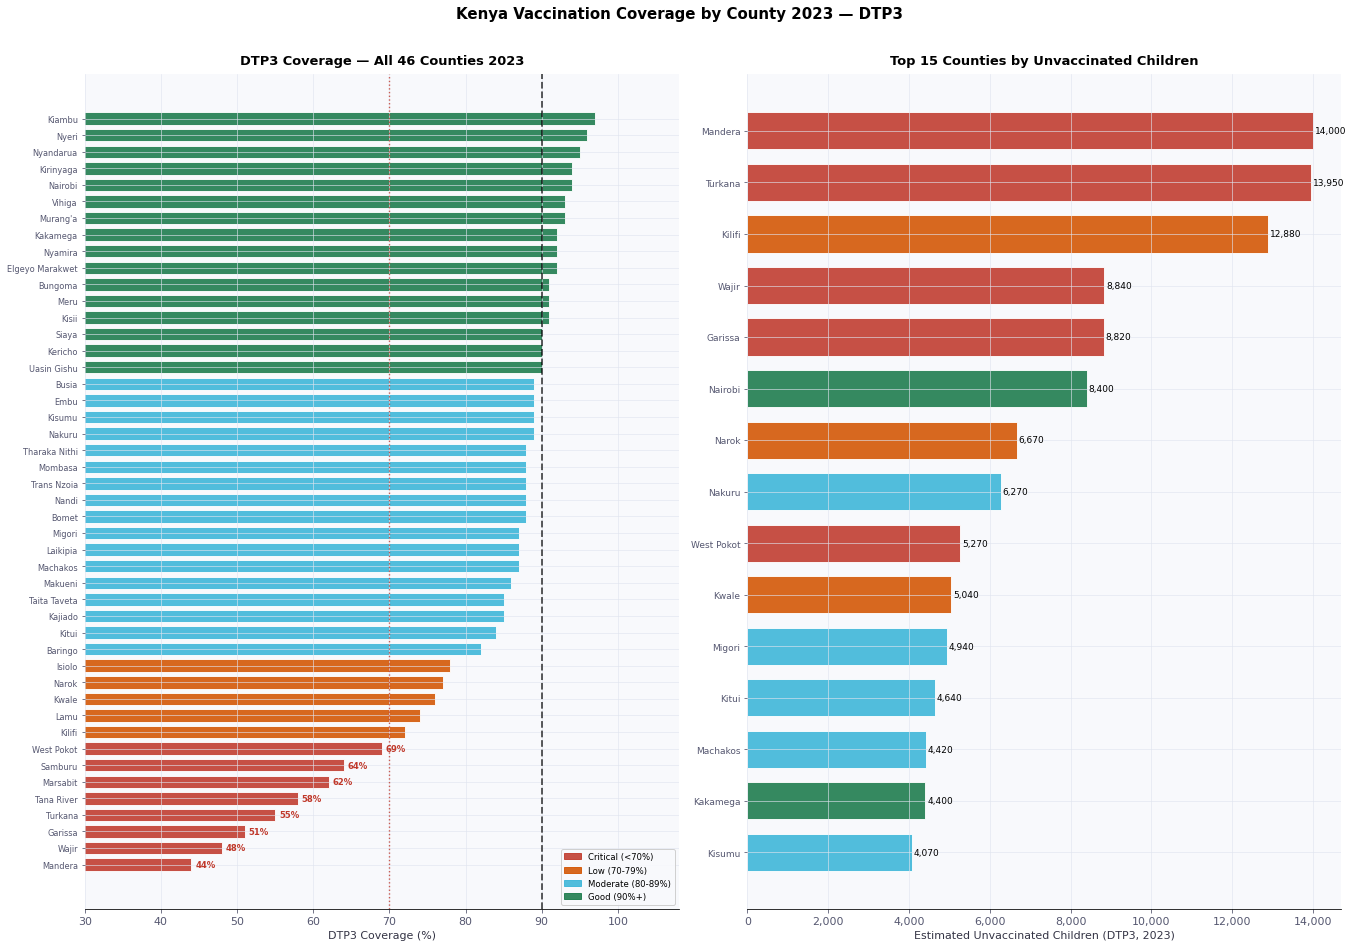

CRITICAL COUNTIES — DTP3 below 70%: 8 counties
────────────────────────────────────────────────────────────────────
  County            Region            DTP3    Unvac.  Birth cohort
  ──────────────────────────────────────────────────────────────
  Mandera           North Eastern      44%   14,000  ( 56.0% unvac.)
  Wajir             North Eastern      48%    8,840  ( 52.0% unvac.)
  Garissa           North Eastern      51%    8,820  ( 49.0% unvac.)
  Turkana           Rift Valley        55%   13,950  ( 45.0% unvac.)
  Tana River        Coast              58%    3,360  ( 42.0% unvac.)
  Marsabit          Rift Valley        62%    3,040  ( 38.0% unvac.)
  Samburu           Rift Valley        64%    2,520  ( 36.0% unvac.)
  West Pokot        Rift Valley        69%    5,270  ( 31.0% unvac.)

  Total unvaccinated children (all 46 counties): 185,450
  From critical counties only:                    59,800 (32.2%)


In [14]:
#  Chart 5: County-level DTP3 coverage — all 46 counties
fig, axes = plt.subplots(1, 2, figsize=(19, 13))
fig.suptitle('Kenya Vaccination Coverage by County 2023 — DTP3', fontsize=15, fontweight='bold', y=1.01)

df_c = df_county.sort_values('DTP3_2023', ascending=True).copy()

coverage_colors = {
    'Critical (<70%)'   : RED,
    'Low (70-79%)'      : ORANGE,
    'Moderate (80-89%)' : SKY,
    'Good (90%+)'       : GREEN,
}
bar_colors = [coverage_colors.get(cat, GREY) for cat in df_c['Coverage_Category']]

# Left: all 46 counties ranked
bars = axes[0].barh(df_c['County'], df_c['DTP3_2023'],
                    color=bar_colors, alpha=0.88, edgecolor='white', height=0.75)
axes[0].axvline(WHO_TARGET, color='black', linewidth=1.8, linestyle='--', alpha=0.7, label='90% WHO target')
axes[0].axvline(70, color=RED, linewidth=1.4, linestyle=':', alpha=0.8, label='70% critical threshold')
axes[0].set_xlabel('DTP3 Coverage (%)', fontsize=11)
axes[0].set_title('DTP3 Coverage — All 46 Counties 2023', fontsize=13, pad=10)
axes[0].set_xlim(30, 108)
axes[0].tick_params(axis='y', labelsize=8.2)

# Coverage category legend
patches = [mpatches.Patch(color=c, label=l, alpha=0.88) for l, c in coverage_colors.items()]
target_line = mpatches.Patch(facecolor='none', edgecolor='black', linestyle='--', label='90% WHO target')
axes[0].legend(handles=patches, fontsize=8.5, loc='lower right')

# Value labels for critical counties
for bar, val, cat in zip(bars, df_c['DTP3_2023'], df_c['Coverage_Category']):
    if 'Critical' in str(cat):
        axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{val}%', va='center', fontsize=8.5, color=RED, fontweight='bold')

# Right: top 15 counties by unvaccinated children
df_top = df_c.nlargest(15, 'Unvaccinated_DTP3').sort_values('Unvaccinated_DTP3', ascending=True)
colors_uc = [coverage_colors.get(cat, GREY) for cat in df_top['Coverage_Category']]

bars2 = axes[1].barh(df_top['County'], df_top['Unvaccinated_DTP3'],
                     color=colors_uc, alpha=0.88, edgecolor='white', height=0.72)
axes[1].set_xlabel('Estimated Unvaccinated Children (DTP3, 2023)', fontsize=11)
axes[1].set_title('Top 15 Counties by Unvaccinated Children', fontsize=13, pad=10)
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
axes[1].tick_params(axis='y', labelsize=9)

for bar, val in zip(bars2, df_top['Unvaccinated_DTP3']):
    axes[1].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=9, fontweight='500')

plt.tight_layout()
plt.savefig('chart_counties.png', dpi=150, bbox_inches='tight')
plt.show()

# Critical counties
critical = df_county[df_county['DTP3_2023'] < 70].sort_values('DTP3_2023')
print(f'CRITICAL COUNTIES — DTP3 below 70%: {len(critical)} counties')
print('─' * 68)
print(f'  {"County":<16}  {"Region":<15}  {"DTP3":>5}  {"Unvac.":>8}  {"Birth cohort":>12}')
print('  ' + '─' * 62)
for _, row in critical.iterrows():
    pct_unvac = row["Unvaccinated_DTP3"] / row["Birth_Cohort"] * 100
    print(f'  {row["County"]:<16}  {row["Region"]:<15}  {row["DTP3_2023"]:>4}%  {row["Unvaccinated_DTP3"]:>7,}  ({pct_unvac:>5.1f}% unvac.)')

total_unvac = df_county['Unvaccinated_DTP3'].sum()
crit_unvac  = critical['Unvaccinated_DTP3'].sum()
print(f'\n  Total unvaccinated children (all 46 counties): {total_unvac:,}')
print(f'  From critical counties only:                    {crit_unvac:,} ({crit_unvac/total_unvac*100:.1f}%)')

**The geography of under-vaccination**

The county ranking reveals a clear geographic pattern. The eight critical counties — all below 70% — are concentrated in two clusters: the North Eastern region (Mandera, Wajir, Garissa) and the arid and semi-arid Rift Valley (Turkana, West Pokot, Samburu, Marsabit) plus Tana River on the coast. These are not randomly distributed. They are the same counties that consistently underperform on maternal health, nutrition and other primary health care indicators.

Mandera at 44% is the worst-performing county. This means more than half of all children born in Mandera in 2023 did not complete their DTP vaccination schedule. Wajir at 48% and Garissa at 51% are only marginally better. These three North Eastern counties together account for approximately 31,660 unvaccinated children — nearly a third of all unvaccinated children from critical counties.

The unvaccinated children chart (right panel) adds an important dimension. Nairobi appears near the top of the unvaccinated children list despite having 94% DTP3 coverage — because its birth cohort of 140,000 is so large that even 6% uncovered represents 8,400 children. This is the urban equity problem: high-density urban settings generate large absolute numbers of unvaccinated children even when percentage coverage is relatively high. The policy response for Nairobi is different from the policy response for Mandera.

---

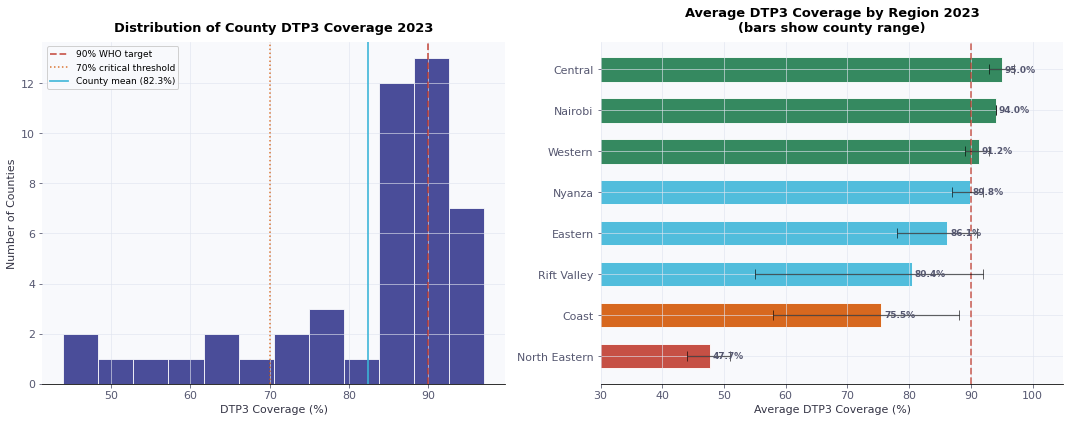


REGIONAL SUMMARY — DTP3 2023
────────────────────────────────────────────────────────────────────────
  Region            Counties   Avg DTP3         Range     Unvac    Critical
  ────────────────────────────────────────────────────────────────────
  North Eastern            3      47.7%        44–51%    31,660          3
  Coast                    6      75.5%        58–88%    27,510          1
  Rift Valley             15      80.4%        55–92%    60,920          4
  Eastern                  7      86.1%        78–91%    20,630          0
  Nyanza                   5      89.8%        87–92%    17,550          0
  Western                  4      91.2%        89–93%    12,330          0
  Nairobi                  1      94.0%        94–94%     8,400          0
  Central                  5      95.0%        93–97%     6,450          0


In [15]:
# County performance distribution and regional breakdown 
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: coverage distribution histogram
axes[0].hist(df_county['DTP3_2023'], bins=12, color=NAVY, alpha=0.8, edgecolor='white')
axes[0].axvline(WHO_TARGET, color=RED, linewidth=1.8, linestyle='--', label='90% WHO target', alpha=0.8)
axes[0].axvline(70, color=ORANGE, linewidth=1.5, linestyle=':', label='70% critical threshold', alpha=0.8)
axes[0].axvline(df_county['DTP3_2023'].mean(), color=SKY, linewidth=1.8, linestyle='-', label=f'County mean ({df_county["DTP3_2023"].mean():.1f}%)', alpha=0.9)
axes[0].set_xlabel('DTP3 Coverage (%)', fontsize=11)
axes[0].set_ylabel('Number of Counties', fontsize=11)
axes[0].set_title('Distribution of County DTP3 Coverage 2023', fontsize=13, pad=10)
axes[0].legend(fontsize=9)

# Right: regional summary
regional_summary = df_county.groupby('Region').agg(
    Counties=('County','count'),
    Avg_DTP3=('DTP3_2023','mean'),
    Min_DTP3=('DTP3_2023','min'),
    Max_DTP3=('DTP3_2023','max'),
    Total_Unvac=('Unvaccinated_DTP3','sum'),
    Critical_Counties=('DTP3_2023', lambda x: (x < 70).sum())
).reset_index().sort_values('Avg_DTP3', ascending=True)

region_colors = [RED if avg < 70 else (ORANGE if avg < 80 else (SKY if avg < 90 else GREEN))
                 for avg in regional_summary['Avg_DTP3']]

bars = axes[1].barh(regional_summary['Region'], regional_summary['Avg_DTP3'],
                    color=region_colors, alpha=0.88, edgecolor='white', height=0.6)
axes[1].axvline(WHO_TARGET, color=RED, linewidth=1.8, linestyle='--', alpha=0.7)
axes[1].set_xlabel('Average DTP3 Coverage (%)', fontsize=11)
axes[1].set_title('Average DTP3 Coverage by Region 2023\n(bars show county range)', fontsize=13, pad=10)
axes[1].set_xlim(30, 105)

# Error bars for range
for _, row in regional_summary.iterrows():
    idx = list(regional_summary['Region']).index(row['Region'])
    axes[1].errorbar(row['Avg_DTP3'], idx,
                     xerr=[[row['Avg_DTP3']-row['Min_DTP3']], [row['Max_DTP3']-row['Avg_DTP3']]],
                     fmt='none', color='black', capsize=5, linewidth=1.2, alpha=0.6)
    axes[1].text(row['Avg_DTP3'] + 0.5, idx, f'{row["Avg_DTP3"]:.1f}%',
                 va='center', fontsize=9, fontweight='bold', color=MID)

plt.tight_layout()
plt.savefig('county_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nREGIONAL SUMMARY — DTP3 2023')
print('─' * 72)
print(f'  {"Region":<16}  {"Counties":>8}  {"Avg DTP3":>9}  {"Range":>12}  {"Unvac":>8}  {"Critical":>10}')
print('  ' + '─' * 68)
for _, row in regional_summary.sort_values('Avg_DTP3').iterrows():
    rng = f'{row["Min_DTP3"]:.0f}–{row["Max_DTP3"]:.0f}%'
    print(f'  {row["Region"]:<16}  {row["Counties"]:>8}  {row["Avg_DTP3"]:>8.1f}%  {rng:>12}  {row["Total_Unvac"]:>8,}  {row["Critical_Counties"]:>9}')

**The regional pattern is stark**

North Eastern Kenya has the lowest average DTP3 coverage of any region — pulled down by Mandera, Wajir and Garissa, all in critical territory. The Rift Valley has the widest range: some counties in the Rift Valley (Uasin Gishu at 90%, Elgeyo Marakwet at 92%) are performing well, while others (Turkana, West Pokot, Samburu, Marsabit) are in the critical category. The intra-regional variation in the Rift Valley is the largest of any region in Kenya.

Central region is the strongest performer. Kiambu (97%), Nyeri (96%), Murang'a (93%), Kirinyaga (94%) and Nyandarua (95%) all exceed the WHO 90% target — the only region in Kenya where every single county is at or above target.

---

<a id='s8'></a>
## 8. Zero-Dose Children

Zero-dose children are defined as infants who have received no routine vaccines at all — not even the first dose of DTP. They are the hardest-to-reach children in any health system, typically concentrated among households with the least access to health services: remote rural communities, nomadic and pastoralist populations, urban informal settlements and refugee populations.

Kenya's 2023 estimate of 207,000 zero-dose children represents a significant improvement from 255,000 in 2019 — a reduction of 48,000 children over four years. But the 2021 COVID spike to 280,000 shows how quickly gains can be lost when health systems are disrupted. The recovery since 2021 has been faster than expected, which suggests the zero-dose reduction programme was operating before COVID and resumed effectively afterward.

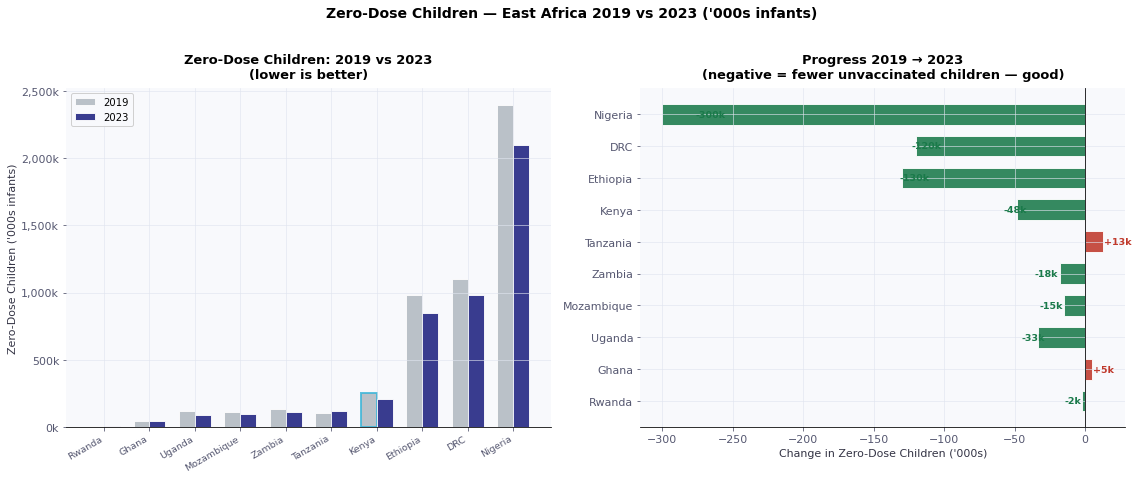

KENYA ZERO-DOSE SNAPSHOT
────────────────────────────────────────────────
  2019: 255k zero-dose children
  2021: 280k (COVID spike — +25k)
  2023: 207k (current estimate)
  Change 2019→2023: -48k (-18.8%)
  DTP1 coverage 2023: 89%

REGIONAL CONTEXT:
  Rwanda           2023:      4k  ↓ Improving
  Ghana            2023:     45k  ↑ Worsening
  Uganda           2023:     87k  ↓ Improving
  Mozambique       2023:     95k  ↓ Improving
  Zambia           2023:    112k  ↓ Improving
  Tanzania         2023:    118k  ↑ Worsening
  Kenya            2023:    207k  ↓ Improving
  Ethiopia         2023:    850k  ↓ Improving
  DRC              2023:    980k  ↓ Improving
  Nigeria          2023:  2,100k  ↓ Improving


In [16]:
#Chart 6: Zero-dose children analysis 
fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle("Zero-Dose Children — East Africa 2019 vs 2023 ('000s infants)",
             fontsize=14, fontweight='bold', y=1.02)

df_z = df_zd.sort_values('Zero_Dose_2023', ascending=True).copy()

# Left: grouped bar 2019 vs 2023
x = np.arange(len(df_z))
w = 0.35
b1 = axes[0].bar(x - w/2, df_z['Zero_Dose_2019'], w, label='2019', color=GREY,  alpha=0.82, edgecolor='white')
b2 = axes[0].bar(x + w/2, df_z['Zero_Dose_2023'], w, label='2023', color=NAVY, alpha=0.88, edgecolor='white')

axes[0].set_xticks(x)
axes[0].set_xticklabels(df_z['Country'], rotation=30, ha='right', fontsize=9.5)
axes[0].set_ylabel("Zero-Dose Children ('000s infants)", fontsize=11)
axes[0].set_title('Zero-Dose Children: 2019 vs 2023\n(lower is better)', fontsize=13, pad=10)
axes[0].legend(fontsize=10)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}k'))

# Highlight Kenya
kenya_idx = list(df_z['Country']).index('Kenya')
axes[0].get_children()[kenya_idx].set_edgecolor(SKY)
axes[0].get_children()[kenya_idx].set_linewidth(2)

# Right: change 2019 → 2023
change       = df_z['Change_2019_to_2023'].values
change_colors = [GREEN if c < 0 else RED for c in change]

bars_ch = axes[1].barh(df_z['Country'], change,
                       color=change_colors, alpha=0.88, edgecolor='white', height=0.65)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel("Change in Zero-Dose Children ('000s)", fontsize=11)
axes[1].set_title('Progress 2019 → 2023\n(negative = fewer unvaccinated children — good)', fontsize=13, pad=10)

for bar, val, country in zip(bars_ch, change, df_z['Country']):
    ha = 'right' if val < 0 else 'left'
    offset = -0.8 if val < 0 else 0.8
    color  = 'white' if abs(val) > 20 else MID
    axes[1].text(val + offset if abs(val) < 20 else val * 0.85,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:+,.0f}k', va='center', ha=ha, fontsize=9.5,
                 color=GREEN if val < 0 else RED, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_zero_dose.png', dpi=150, bbox_inches='tight')
plt.show()

# Kenya detail
k = df_zd[df_zd['Country'] == 'Kenya'].iloc[0]
print('KENYA ZERO-DOSE SNAPSHOT')
print('─' * 48)
print(f'  2019: {k["Zero_Dose_2019"]:,}k zero-dose children')
print(f'  2021: {k["Zero_Dose_2021"]:,}k (COVID spike — +{k["Zero_Dose_2021"]-k["Zero_Dose_2019"]:,}k)')
print(f'  2023: {k["Zero_Dose_2023"]:,}k (current estimate)')
print(f'  Change 2019→2023: {k["Change_2019_to_2023"]:+,}k ({k["Change_2019_to_2023"]/k["Zero_Dose_2019"]*100:+.1f}%)')
print(f'  DTP1 coverage 2023: {k["DTP1_Coverage_2023"]}%')
print()
print('REGIONAL CONTEXT:')
for _, row in df_zd.sort_values('Zero_Dose_2023').iterrows():
    trend = '↓ Improving' if row['Trend'] == 'Improving' else '↑ Worsening'
    print(f'  {row["Country"]:<15}  2023: {row["Zero_Dose_2023"]:>6,}k  {trend}')

**Kenya's zero-dose progress in context**

Kenya's 48,000 reduction in zero-dose children between 2019 and 2023 — an 18.8% decline — is a genuine public health achievement. It is more than what Uganda managed and more in absolute terms than Rwanda (which started with almost no zero-dose children). The COVID spike to 280,000 in 2021 and the subsequent recovery to 207,000 by 2023 is particularly notable — a 26% reduction in two years during a difficult post-pandemic period.

The DTP1 coverage figure of 89% (2023) is important context. 89% DTP1 coverage with 207,000 zero-dose children means that the zero-dose population is already concentrated — these are not evenly distributed households that simply missed a dose. They are the hardest-to-reach communities: pastoralists in Turkana and Marsabit, isolated rural communities in Garissa and Wajir, and urban slum dwellers in Nairobi and Mombasa who fall through the facility-based system.

Tanzania (worsening, +13,000) and Ghana (worsening, +5,000) stand out as the two countries going in the wrong direction despite relatively high DTP3 coverage. This suggests a selective failure — some specific sub-populations are being systematically missed even in countries with strong overall coverage.

---

<a id='s9'></a>
## 9. Vaccine Introduction Timeline & Coverage Gaps

Kenya has introduced 13 vaccines into its routine schedule since 1979. Each introduction represents a policy decision, a supply chain upgrade, a health worker training exercise and a communication campaign. GAVI has supported many of the most recent introductions, covering a portion of vaccine costs for GAVI-eligible countries.

This section examines two things: when each vaccine was introduced and whether GAVI support correlates with coverage success and how large the gap between current coverage and the WHO target is for each antigen.

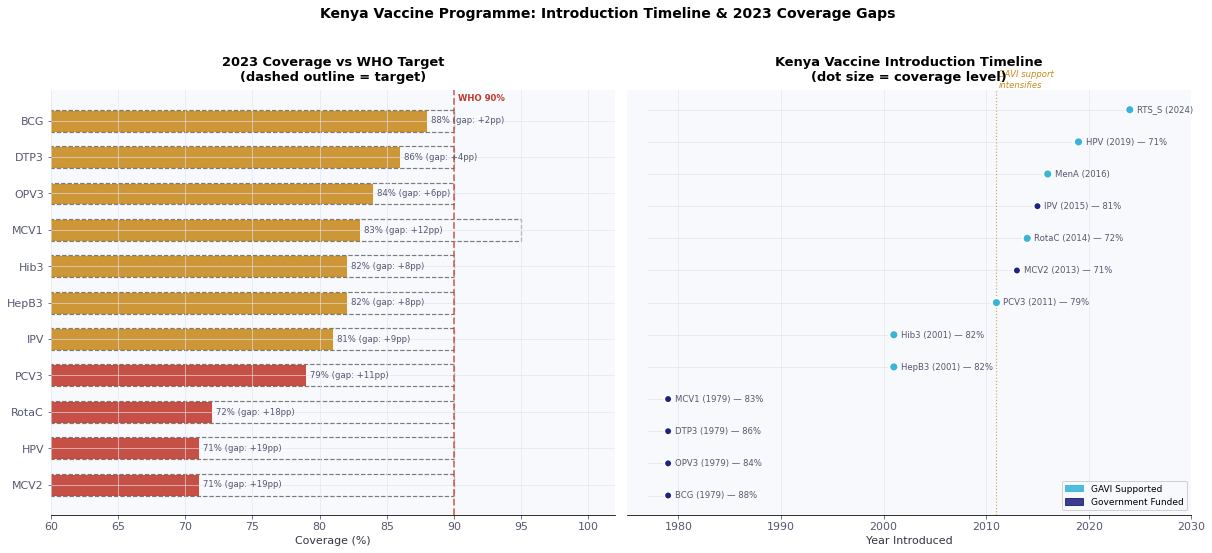

COVERAGE GAPS vs WHO TARGET (2023) — sorted by gap size
────────────────────────────────────────────────────────────
  Antigen    Coverage   Target     Gap   GAVI  Status
  ───────────────────────────────────────────────────────
  MCV2            71%      90%    +19pp     No  ❌
  HPV             71%      90%    +19pp    Yes  ❌
  RotaC           72%      90%    +18pp    Yes  ❌
  MCV1            83%      95%    +12pp     No  ❌
  PCV3            79%      90%    +11pp    Yes  ❌
  IPV             81%      90%     +9pp     No  ❌
  HepB3           82%      90%     +8pp    Yes  ❌
  Hib3            82%      90%     +8pp    Yes  ❌
  OPV3            84%      90%     +6pp     No  ❌
  DTP3            86%      90%     +4pp     No  ❌
  BCG             88%      90%     +2pp     No  ❌


In [17]:
# Chart 7: Introduction timeline and coverage gaps 
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
fig.suptitle('Kenya Vaccine Programme: Introduction Timeline & 2023 Coverage Gaps',
             fontsize=14, fontweight='bold', y=1.02)

df_i = df_intro.dropna(subset=['Coverage_2023_pct']).copy()
df_i = df_i.sort_values('Coverage_2023_pct', ascending=True)

# Left: coverage vs target bar chart
bar_colors_i = []
for _, row in df_i.iterrows():
    tgt = MCV_TARGET if row['Vaccine_Code'] in ['MCV1','MCV2'] else WHO_TARGET
    if row['Coverage_2023_pct'] >= tgt:
        bar_colors_i.append(GREEN)
    elif row['Coverage_2023_pct'] >= 80:
        bar_colors_i.append(AMBER)
    else:
        bar_colors_i.append(RED)

bars_i = axes[0].barh(df_i['Vaccine_Code'], df_i['Coverage_2023_pct'],
                      color=bar_colors_i, alpha=0.88, edgecolor='white', height=0.6)

# WHO target as an outline bar
axes[0].barh(df_i['Vaccine_Code'], df_i['WHO_Target_pct'],
             color='none', edgecolor='black', linewidth=1.2, height=0.6,
             linestyle='--', alpha=0.5)

axes[0].axvline(WHO_TARGET, color=RED, linewidth=1.8, linestyle='--', alpha=0.7)
axes[0].text(WHO_TARGET + 0.3, 10.5, 'WHO 90%', fontsize=8.5, color=RED, va='bottom', fontweight='bold')
axes[0].set_xlabel('Coverage (%)', fontsize=11)
axes[0].set_title('2023 Coverage vs WHO Target\n(dashed outline = target)', fontsize=13, pad=10)
axes[0].set_xlim(60, 102)

for bar, val, gap in zip(bars_i, df_i['Coverage_2023_pct'], df_i['Gap_pp']):
    axes[0].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f}% (gap: {gap:+.0f}pp)', va='center', fontsize=8.5, color=MID)

# Right: vaccine introduction timeline
df_all = df_intro.sort_values('Year_Introduced_Kenya')
y_pos  = range(len(df_all))
gavi_colors = [SKY if g == 'Yes' else NAVY for g in df_all['GAVI_Supported']]
sizes       = [80  if g == 'Yes' else 60   for g in df_all['GAVI_Supported']]

axes[1].scatter(df_all['Year_Introduced_Kenya'], y_pos,
                c=gavi_colors, s=sizes, zorder=5, edgecolors='white', linewidth=1.8)

for i, (_, row) in enumerate(df_all.iterrows()):
    cov_text = f" — {row['Coverage_2023_pct']:.0f}%" if pd.notna(row['Coverage_2023_pct']) else ''
    label    = f"{row['Vaccine_Code']} ({int(row['Year_Introduced_Kenya'])}){cov_text}"
    axes[1].annotate(label,
                     (row['Year_Introduced_Kenya'], i),
                     textcoords='offset points', xytext=(7, 0),
                     fontsize=8.5, va='center', color=MID)
    axes[1].plot([1977, row['Year_Introduced_Kenya']], [i, i],
                 color=GREY, linewidth=0.5, alpha=0.4, zorder=0)

# GAVI intensification marker
axes[1].axvline(2011, color=AMBER, linewidth=1.2, linestyle=':', alpha=0.7)
axes[1].text(2011.2, 12.7, 'GAVI support\nintensifies', ha='left',
             fontsize=8.5, color=AMBER, style='italic')

gavi_patch   = mpatches.Patch(color=SKY,  label='GAVI Supported', alpha=0.88)
nongavi_patch = mpatches.Patch(color=NAVY, label='Government Funded', alpha=0.88)
axes[1].legend(handles=[gavi_patch, nongavi_patch], fontsize=9, loc='lower right')
axes[1].set_xlabel('Year Introduced', fontsize=11)
axes[1].set_title('Kenya Vaccine Introduction Timeline\n(dot size = coverage level)', fontsize=13, pad=10)
axes[1].set_yticks([])
axes[1].set_xlim(1975, 2030)

plt.tight_layout()
plt.savefig('chart_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print('COVERAGE GAPS vs WHO TARGET (2023) — sorted by gap size')
print('─' * 60)
df_gaps = df_i.sort_values('Gap_pp', ascending=False)
print(f'  {"Antigen":<8}  {"Coverage":>9}  {"Target":>7}  {"Gap":>6}  {"GAVI":>5}  {"Status"}')
print('  ' + '─' * 55)
for _, row in df_gaps.iterrows():
    status = '✅' if row['Gap_pp'] <= 0 else '❌'
    print(f'  {row["Vaccine_Code"]:<8}  {row["Coverage_2023_pct"]:>8.0f}%  {row["WHO_Target_pct"]:>6.0f}%  '
          f'{row["Gap_pp"]:>+5.0f}pp  {row["GAVI_Supported"]:>5}  {status}')

**The coverage gap picture**

Not a single antigen in Kenya's routine schedule currently meets its WHO coverage target. The best performer is BCG at 88%, 2 percentage points below the 90% target — a gap that should be closeable with focused effort on the counties and birth registration systems that miss newborns at birth. DTP3 at 86% has a 4-point gap.

The widest gaps are in the newer vaccines. MCV2 (second measles dose) at 71% has a 19-point gap to the 90% WHO target. HPV at 71% has the same gap. RotaC at 72% has an 18-point gap. These three antigens were all introduced after 2013 and represent the programme's most significant equity challenge: they protect against diseases (measles, cervical cancer, diarrhoeal disease) that disproportionately affect children in low-income households and rural areas, yet they have the lowest coverage of any vaccines in the schedule.

The GAVI support variable is interesting but inconclusive. GAVI-supported vaccines do not obviously outperform non-GAVI vaccines in terms of coverage — PCV3 (GAVI supported, 79%) performs similarly to OPV3 (not GAVI supported, 84%). This suggests that supply-side financing, which GAVI primarily addresses, is not the binding constraint on coverage for the newer vaccines. The constraint is on the demand and delivery side — reaching the households that are not engaging with the health system at all.

---

<a id='s10'></a>
## 10. Export for Power BI

The source file `Vaccination_Coverage_Dataset.xlsx` is structured for direct import into Power BI — each sheet maps cleanly to a dashboard page. The analysis in this notebook produces six chart exports that can also be embedded as static visuals in the dashboard for context pages that do not require interactivity.

In [18]:
# Power BI import guide 
import os

xl = pd.ExcelFile('Vaccination_Coverage_Dataset.xlsx')

print('POWER BI IMPORT REFERENCE')
print('=' * 70)
print()
print('Connection method:')
print('  Get Data → Excel Workbook → Vaccination_Coverage_Dataset.xlsx')
print('  Navigator → select all 5 sheets → Load')
print()

mapping = {
    'Kenya_Trend_2000_2024'       : 'Page 2 & 3 — trend charts, COVID analysis, dropout tracking',
    'Regional_Comparison'          : 'Page 1 — executive overview, regional benchmarking',
    'Kenya_47_Counties'            : 'Page 4 — county choropleth, subnational drilldown',
    'Vaccine_Introduction_Timeline': 'Page 5 — timeline visual, gap-to-target bars',
    'Zero_Dose_Analysis'           : 'Page 3 — zero-dose children equity analysis',
}

for sheet in xl.sheet_names:
    df_tmp = pd.read_excel('Vaccination_Coverage_Dataset.xlsx', sheet_name=sheet)
    page   = mapping.get(sheet, '')
    print(f'  Sheet: {sheet}')
    print(f'    Rows × Cols : {df_tmp.shape[0]} × {df_tmp.shape[1]}')
    print(f'    Dashboard   : {page}')
    key_cols = [c for c in df_tmp.columns if not c.startswith('Unnamed')][:5]
    print(f'    Key columns : {", ".join(key_cols)}')
    print()

print()
print('Live OData connection (auto-refreshes from WHO):')
print('  Get Data → OData Feed')
print('  DTP3  : https://ghoapi.azureedge.net/api/WHS4_100')
print('  MCV1  : https://ghoapi.azureedge.net/api/WHS4_117')
print('  BCG   : https://ghoapi.azureedge.net/api/WHS4_543')
print('  No authentication required for any of these endpoints')
print()

# Chart exports
print('CHART FILES GENERATED')
print('─' * 48)
charts = ['kenya_trend.png','kenya_dropout.png','covid_impact.png',
          'regional.png','chart_counties.png','county_distribution.png',
          'chart_zero_dose.png','chart_timeline.png']
for c in charts:
    exists = '✅' if os.path.exists(c) else '⬜ (will generate when cells run)'
    print(f'  {exists}  {c}')

POWER BI IMPORT REFERENCE

Connection method:
  Get Data → Excel Workbook → Vaccination_Coverage_Dataset.xlsx
  Navigator → select all 5 sheets → Load

  Sheet: Kenya_Trend_2000_2024
    Rows × Cols : 25 × 17
    Dashboard   : Page 2 & 3 — trend charts, COVID analysis, dropout tracking
    Key columns : Year, BCG, DTP1, DTP3, OPV3

  Sheet: Regional_Comparison
    Rows × Cols : 11 × 19
    Dashboard   : Page 1 — executive overview, regional benchmarking
    Key columns : Country, ISO3, WHO_Region, Income_Group, GAVI_Eligible

  Sheet: Kenya_47_Counties
    Rows × Cols : 46 × 14
    Dashboard   : Page 4 — county choropleth, subnational drilldown
    Key columns : County, County_Code, Region, Urbanization, BCG_2023

  Sheet: Vaccine_Introduction_Timeline
    Rows × Cols : 13 × 10
    Dashboard   : Page 5 — timeline visual, gap-to-target bars
    Key columns : Vaccine_Code, Vaccine_Full_Name, Year_Introduced_Kenya, Schedule, Coverage_2023_pct

  Sheet: Zero_Dose_Analysis
    Rows × Cols :

<a id='s11'></a>
## 11. Key Findings & Dashboard Blueprint

### What this analysis shows

This project started as an EDA. What it found is a consistent story across every analytical lens applied: Kenya's immunisation programme has real achievements behind it, a significant COVID disruption in its recent history and structural equity gaps that have not narrowed proportionally with overall coverage improvements.

---

### The seven findings that matter

**1. No antigen meets its WHO target.**
Every vaccine in Kenya's routine schedule is below its WHO IA2030 coverage target. BCG is closest at 88% (gap: 2pp). MCV2 and HPV are furthest at 71–72% (gaps: 18–19pp). This is the headline fact the dashboard should communicate first.

**2. The COVID setback is partially recovered — but only partially.**
DTP3 fell from 87% in 2019 to 79% in 2021. By 2024 it has recovered to 85% — 6 percentage points of the 8-point drop have been recovered. The recovery is real but incomplete and for newer antigens like MCV2 and RotaC, the recovery is even slower.

**3. Eight counties are in critical territory.**
Mandera (44%), Wajir (48%), Garissa (51%), Tana River (58%), Turkana (55%), Marsabit (62%), Samburu (64%) and West Pokot (69%) are all below the 70% threshold below which outbreak risk is meaningfully elevated. These are geographically contiguous — concentrated in the ASAL belt across the north and northwest.

**4. The equity gap between best and worst county is 52 percentage points.**
Nyeri (96%) and Mandera (44%) are separated by more than 50 percentage points. This is not a measurement artefact. It reflects fundamentally different health system access, community health worker density and cold chain coverage between Central Kenya and the Arid North East.

**5. Approximately 185,000 children are unvaccinated for DTP3 across the 46 counties.**
This is a 2023 estimate derived from birth cohort sizes and coverage rates. About 32% of these children are concentrated in the eight critical counties. The remaining 68% are in counties with moderate or good average coverage — meaning they represent pockets within otherwise better-performing counties.

**6. Kenya has 207,000 zero-dose children — improving.**
Down from 255,000 in 2019 and 280,000 at the COVID peak in 2021. The downward trend is positive but 207,000 zero-dose infants is still a substantial number for a country with Kenya's immunisation infrastructure.

**7. Rwanda is the benchmark, not an exception.**
Rwanda achieves 99% DTP3 coverage with a similar income level and geographic context. The gap between Kenya and Rwanda is a programme design and delivery gap, not a resource gap that Kenya cannot close.

---

### Recommended Power BI Dashboard — 5 Page Structure

**Page 1 — Executive Overview**
Four KPI cards (DTP3 2024, MCV1 2024, zero-dose children 2023, counties below 70%) all flagged in red against their targets. Regional bar chart showing Kenya vs neighbours. One sparkline per antigen showing trend direction.

**Page 2 — Kenya Coverage Trends (2000 – 2024)**
Multi-line trend chart with all antigens, WHO target line, COVID band highlighted 2020–2021. Year range slicer. Antigen filter. DTP1 → DTP3 dropout rate secondary chart.

**Page 3 — COVID Disruption & Recovery**
Pre-COVID vs trough vs 2024 recovery grouped bar. Recovery percentage tile per antigen. Zero-dose 2019 / 2021 / 2023 trend line.

**Page 4 — County Drilldown (the flagship page)**
Kenya choropleth map — counties coloured by coverage category (Red/Amber/Sky/Green). Ranked bar chart — all 46 counties from worst to best. Unvaccinated children count. Region filter. Urbanisation filter.

**Page 5 — Vaccine Gaps & Introduction Timeline**
Gap-to-target horizontal bar (sorted by gap size). Introduction timeline scatter. GAVI vs non-GAVI comparison. IA2030 progress indicator.

---

### Recommended colour scheme for Power BI

| Coverage | Colour | Hex | Use for |
|:---|:---|:---|:---|
| Critical — below 70% | Red | `#C0392B` | Critical counties, far-from-target bars |
| Low — 70–79% | Orange | `#D35400` | Below-average performance |
| Moderate — 80–89% | Sky Blue | `#3AB5D8` | Near-target performance |
| On Target — 90%+ | Green | `#1A7A4A` | Meeting or exceeding WHO target |
| Kenya / Primary | Navy | `#1E2280` | Highlight colour, Kenya-specific elements |

---

*Analysis by Patience Anono — PA Data Analytics · padataanalytics.com*